<a href="https://colab.research.google.com/github/ShashikanthKungulwar/CV_practice/blob/main/cifar10_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import tensorflow as tf
from keras.datasets import cifar10
import matplotlib.pyplot as plt


In [43]:
(x_train,y_train),(x_test,y_test) = cifar10.load_data()

In [44]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

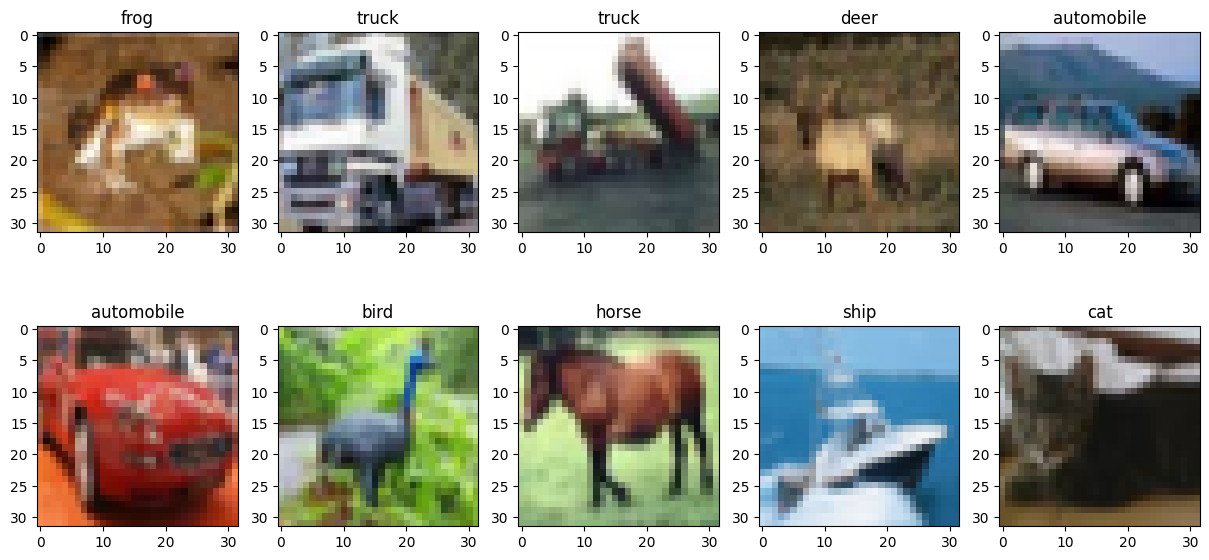

In [45]:
labels=["airplane",
"automobile",
"bird",
"cat",
"deer",
"dog",
"frog",
"horse",
"ship",
"truck"]

fig,axes =  plt.subplots(2,5,figsize=(15,7))
for i in range(10):
  axes[i//5][i%5].imshow(x_train[i])
  axes[i//5,i%5].set_title(labels[y_train[i][0]])



In [46]:
# data preporcessing
from keras.utils import to_categorical

x_train = x_train.astype("float32")/255
x_test = x_test.astype("float32")/255


y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [47]:
y_train.shape,y_test.shape

((50000, 10), (10000, 10))

In [48]:
# # train and validation test

# x_train,x_val = x_train[5000:],x_train[:5000]
# y_train,y_val = y_train[5000:],y_train[:5000]

# not required

In [54]:
# model  architecture


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dropout,Flatten,Dense


model = Sequential()
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation = "relu",
    input_shape=(32,32,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))



model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation = "relu",
    input_shape=(32,32,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(128,activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(10,activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=['accuracy'])

In [56]:
from keras.callbacks import ModelCheckpoint
checkpointer = ModelCheckpoint(
    filepath='model.weights.best.keras',
    verbose=1,
    save_best_only=True
)


model.fit(x_train,y_train,validation_split=0.2,epochs=10,batch_size=64,callbacks=[checkpointer],shuffle=True)
#

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.2819 - loss: 1.9292
Epoch 1: val_loss improved from None to 1.35236, saving model to model.weights.best.keras

Epoch 1: finished saving model to model.weights.best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 89ms/step - accuracy: 0.3697 - loss: 1.7148 - val_accuracy: 0.5192 - val_loss: 1.3524
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4811 - loss: 1.4304
Epoch 2: val_loss improved from 1.35236 to 1.21811, saving model to model.weights.best.keras

Epoch 2: finished saving model to model.weights.best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.4992 - loss: 1.3963 - val_accuracy: 0.5693 - val_loss: 1.2181
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5474 - loss: 1.2812
Epoch 3: val_loss improved from 1.21811 to 1.12033, saving model to model.weights.best.keras

Epoch 3: finished saving model to model.weights.best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - 

In [57]:
model.load_weights("model.weights.best.keras")

score = model.evaluate(x_test,y_test,verbose=0)
print(score)
# index 1 is accuracy
# index 0 is loss



[0.8944751024246216, 0.684499979019165]


In [58]:
y_pred_test = model.predict(x_test)
y_pred_test.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


(10000, 10)

In [59]:
y_pred_test = y_pred_test.argmax(axis=1)

In [61]:
y_pred_test.shape

(10000,)

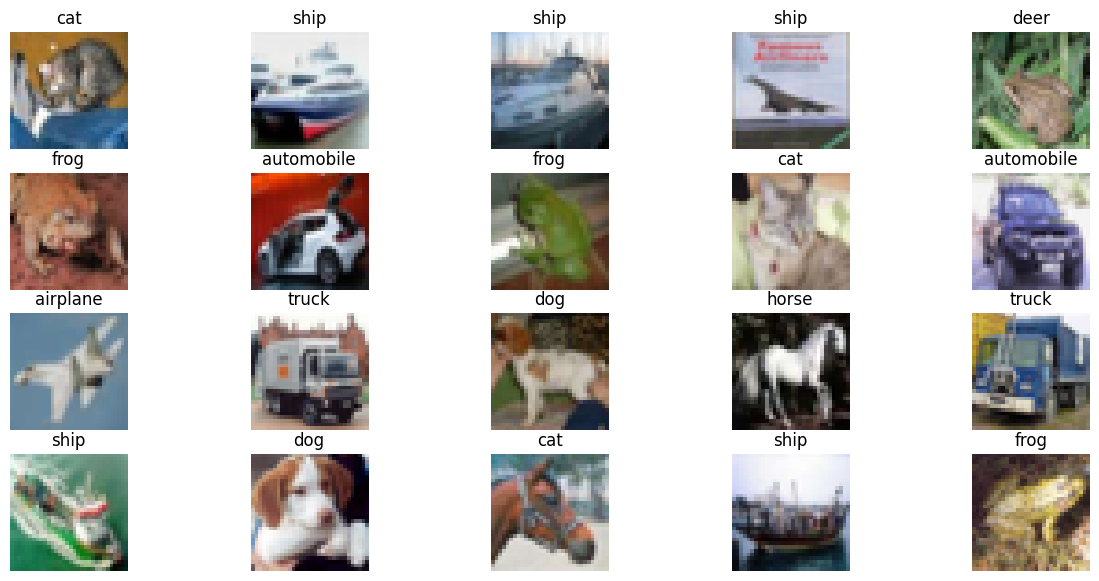

In [66]:
labels=["airplane",
"automobile",
"bird",
"cat",
"deer",
"dog",
"frog",
"horse",
"ship",
"truck"]

fig,axes =  plt.subplots(4,5,figsize=(15,7))
for i in range(20):
  axes[i//5][i%5].imshow(x_test[i])
  axes[i//5,i%5].set_title(labels[y_pred_test[i]])
  axes[i//5,i%5].axis("off")
